# Limit contour: event list → excluded $(m_\text{DM}, \alpha_n)$ region

**Private.** The successor to `12_limit_atmos`: same physics chain
(SHM halo → atmospheric attenuation → straight-line $K_1$ cross section →
$dR/dq$), but the limit is set with the public
[`optimum_interval`](https://github.com/tunnell/optimum_interval) package
instead of the $\langle N\rangle = 3$ rule, so it handles observed candidate
events without a background model.

**Division of labor**: conversions and machinery (the $K_1$ interpolants, the
rate → extremeness plumbing) live in the `luhdm` package; the things we tweak —
the rate formula, halo/attenuation choices, grids, exposure, and the event
list — live here.

**Input**: the `EVENTS` array below (one random candidate kick for the
non-background-free case). **Output**: the 95% CL excluded contour, with the
$\langle N\rangle = 3$ zero-event contour for reference.

Because the spectrum shape depends on $\alpha_n$ (finite-range cross section
*and* attenuation), we scan the coupling plane and take level sets of the
extremeness surface — `upper_limit` does not apply directly.


In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np

from luhdm import atmosphere, config, cross_section, halo, limits, units

# fiducials, as in 12_limit_atmos cell 18
LAMB = 3e-3                       # mediator range [m]
R_eff = config.R_EFF
Q_THRESH = config.Q_THRESH
T_TOTAL = 3600 * 24 * 7 * 2      # 2 weeks in seconds
CONFIDENCE = 0.95

np.random.seed(20260702)         # luhdm samplers use legacy np.random
print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"xi = {R_eff / LAMB:.3f}")

N_n = 2.51e+20   q_th = 8400 GeV   xi = 0.087


## Input: the event list

One candidate kick drawn at random just above threshold. **Replace this array
with the reconstructed kicks from data and rerun — nothing else changes.**


In [2]:
rng = np.random.default_rng(20260702)
EVENTS = 10 ** rng.uniform(np.log10(Q_THRESH), np.log10(3 * Q_THRESH), size=1)
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12625.]


## Cross-section interpolant

One-time tabulation of the dimensionless $d\sigma/d\tilde q$ (now provided by
`luhdm.cross_section`, same call as before).


In [3]:
print("Computing dsigma_dq interpolant...")
interpolant = cross_section.make_dsigma_dq_interpolant(1e-25, R_eff, LAMB)
print("Done")

Computing dsigma_dq interpolant...


  0%|          | 0/1000 [00:00<?, ?it/s]

~/code/luhdm/luhdm/cross_section.py:273: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, _ = quad(integrand, 0, t_max, limit=100)
  0%|          | 2/1000 [00:00<00:50, 19.59it/s]

~/code/luhdm/luhdm/cross_section.py:273: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(integrand, 0, t_max, limit=100)
  0%|          | 4/1000 [00:00<00:51, 19.21it/s]

  1%|          | 7/1000 [00:00<00:49, 20.02it/s]

...

 93%|█████████▎| 931/1000 [00:29<00:00, 87.61it/s]

 94%|█████████▍| 940/1000 [00:29<00:00, 87.69it/s]

 95%|█████████▌| 951/1000 [00:29<00:00, 92.56it/s]

100%|██████████| 1000/1000 [00:29<00:00, 33.88it/s]

Done


## Differential rate — the physics to tweak

Same formula and notation as `12_limit_atmos` (`mu` is the DM mass in the
original notation); only the rate conversion constant moved to `luhdm.units`.


In [4]:
def differential_rate_trapz(qs, alpha_n, lamb, mu, R_eff, f_v_f, dsigma_interpolant):
    '''dR/dq via trapz (mu = m_DM in the original notation).'''
    alpha = alpha_n * config.N_NEUTRONS
    n_dm = halo.number_density_dm(mu)

    # Precompute f_vf on a fixed grid spanning all v_mins
    v_min_global = qs.min() / mu
    vs_global = np.geomspace(v_min_global, config.VESC, 500)
    f_vf_grid = f_v_f(vs_global)  # KDE evaluated once

    results = []
    for q in qs:
        v_min = q / mu
        mask = vs_global >= v_min
        vs = vs_global[mask]
        fvf = f_vf_grid[mask]
        integrand = n_dm * fvf * vs * cross_section.dsigma_dq(
            q, alpha, lamb, R_eff, vs, dsigma_interpolant)
        results.append(np.trapezoid(integrand, vs) * units.CONV2RATE)

    return np.maximum(np.array(results), 0)


v_i_samples = atmosphere.sample_shm(int(1e5))  # SHM at the top of the atmosphere

## Spectra

The attenuated $dR/dq$ for a few masses at fixed coupling (the analog of the
spectra figure in `12_limit_atmos`).


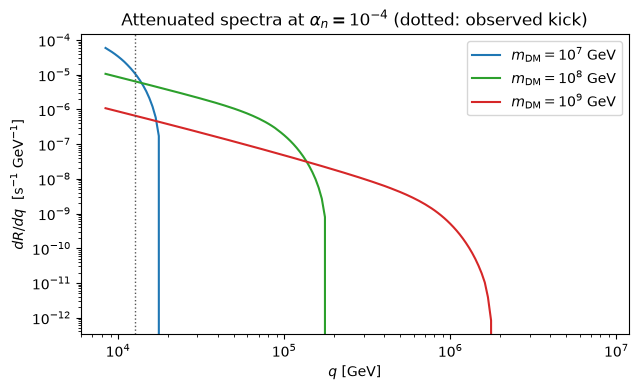

In [5]:
ALPHA_N_SHOW = 1e-4
qs_plot = np.geomspace(Q_THRESH, 1000 * Q_THRESH, 160)

fig, ax = plt.subplots(figsize=(6.5, 4))
for m, color in [(1e7, "#1f77b4"), (1e8, "#2ca02c"), (1e9, "#d62728")]:
    v_min = qs_plot.min() / m / 10
    v_f_samples = atmosphere.compute_v_f_distribution(
        ALPHA_N_SHOW, LAMB, m, v_i_samples, v_min=v_min, n_grid=80)
    f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
    ax.loglog(qs_plot,
              differential_rate_trapz(qs_plot, ALPHA_N_SHOW, LAMB, m, R_eff,
                                      f_v_f, interpolant),
              color=color, label=rf"$m_{{\rm DM}} = 10^{{{int(np.log10(m))}}}$ GeV")
for q_ev in EVENTS:
    ax.axvline(q_ev, color="#555555", lw=1, ls=":")
ax.set_xlabel(r"$q$ [GeV]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ GeV$^{-1}$]")
ax.set_title(rf"Attenuated spectra at $\alpha_n = 10^{{-4}}$ "
             "(dotted: observed kick)")
ax.legend()
fig.tight_layout()

## The $(m_\text{DM}, \alpha_n)$ scan

Same double loop as the `counts` grid in `12_limit_atmos`, storing two
surfaces: `counts` (expected events $\mu$, exactly as before) and
`extremeness` (the optimum-interval statistic for `EVENTS`, from
`luhdm.limits`). Monte-Carlo calibration tables are shared across the plane
via $\mu$ rounding.


In [6]:
N_GRID_M, N_GRID_A = 9, 20
ms = np.logspace(6.8, 10, N_GRID_M)
alphas_n = np.logspace(-8.5, -1.5, N_GRID_A)

counts = np.zeros((N_GRID_A, N_GRID_M))
extremeness = np.zeros((N_GRID_A, N_GRID_M))
table = limits.new_table(seed=20260702)

t0 = time.time()
for im, m in enumerate(ms):
    t_m = time.time()
    for ia, alpha_n in enumerate(alphas_n):
        v_min = Q_THRESH / m / 10
        v_f_samples = atmosphere.compute_v_f_distribution(
            alpha_n, LAMB, m, v_i_samples, v_min=v_min, n_grid=80)
        f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
        qs = np.geomspace(Q_THRESH, 1000 * Q_THRESH, 160)
        diff_rate = differential_rate_trapz(qs, alpha_n, LAMB, m, R_eff,
                                            f_v_f, interpolant)
        extremeness[ia, im], counts[ia, im] = limits.extremeness_and_mu(
            table, EVENTS, qs, diff_rate, T_TOTAL)
    print(f"m = {m:.2e} GeV done in {time.time() - t_m:.0f}s")
print(f"total scan: {time.time() - t0:.0f}s ({N_GRID_M * N_GRID_A} points)")

m = 6.31e+06 GeV done in 14s


m = 1.58e+07 GeV done in 13s


m = 3.98e+07 GeV done in 11s


m = 1.00e+08 GeV done in 11s


m = 2.51e+08 GeV done in 12s


m = 6.31e+08 GeV done in 13s


m = 1.58e+09 GeV done in 13s


m = 3.98e+09 GeV done in 13s


m = 1.00e+10 GeV done in 14s
total scan: 112s (180 points)


## Result: the excluded contour

Solid: the 95% CL optimum-interval contour given `EVENTS`. Dashed: the
$\langle N\rangle = 3$ zero-event contour (the old rule) from the same
`counts` surface. The excluded region is an island — floored by the
finite-range momentum cap, ceilinged by atmospheric stopping.


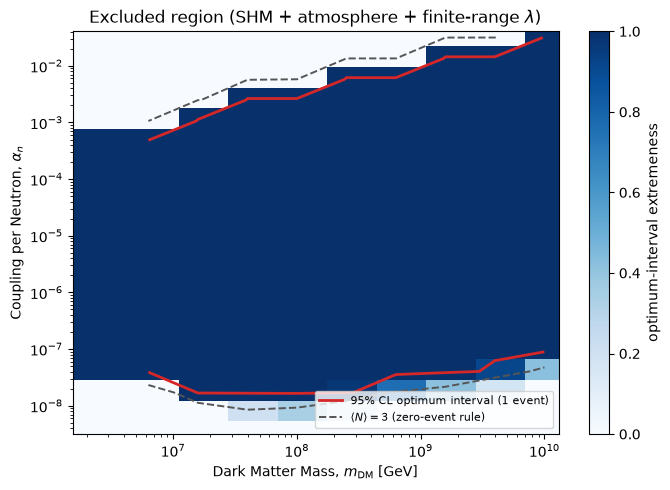

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(ms, alphas_n, extremeness, cmap="Blues",
                     vmin=0, vmax=1, shading="auto")
fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
ax.contour(ms, alphas_n, extremeness, levels=[CONFIDENCE],
           colors="#d62728", linewidths=2)
ax.contour(ms, alphas_n, counts, levels=[3.0], colors="#555555",
           linewidths=1.4, linestyles="--")
ax.plot([], [], color="#d62728", lw=2,
        label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} event)")
ax.plot([], [], color="#555555", lw=1.4, ls="--",
        label=r"$\langle N\rangle = 3$ (zero-event rule)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
ax.set_title(r"Excluded region (SHM + atmosphere + finite-range $\lambda$)")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig("limit_contour.png", dpi=140)

## Notes

- **Data**: replace `EVENTS` and rerun. More candidates only move the
  extremeness surface; the machinery is untouched.
- **Physics tweaks** happen in this notebook: the `differential_rate_trapz`
  formula, the halo/attenuation calls, `LAMB`, the grids, `T_TOTAL`.
- **Knobs**: `n_grid` (attenuation ODE resolution — the runtime driver),
  `n_mc` / `mu_dex` in `limits.extremeness_and_mu`, and the grid densities.
- With zero events the extremeness contour coincides with
  $\langle N\rangle \simeq 3$ at 95% CL by construction, so the old rule is
  recovered exactly in the background-free case.
